## Title

Authors: Armando Romani, Open Brain Institute

Last Modified: 05.2026

_description_

Let's first import some libraries:

In [1]:
from obi_auth import get_token
from entitysdk.client import Client
from entitysdk.common import ProjectContext
from entitysdk.models import Simulation, SimulationCampaign, SimulationResult, SimulationExecution
from obi_auth import get_token
from obi_notebook.get_projects import get_projects
from obi_notebook.get_environment import get_environment
from ipywidgets import widgets
from uuid import UUID
from campaign_helpers import stage_sim_campaign
import json

## Get authentication token and choose a project context

In [2]:
env = "production"
token = get_token(environment=env, auth_mode="daf")
project_context = get_projects(token=token, env=env)

Dropdown(description='Select:', options=(('Testing', {'id': '5ce8c7db-8847-499b-89b2-95612edafad2', 'name': 'T…

## Select SimulationCampaigns
Find and select simulation campaigns.

You should select two campaigns: one for control and one for mutation simulations.

In [3]:
sim1_id = UUID("75a120ce-baec-4b17-ad0e-3d51182a9de6") # range 90-200
sim2_id = UUID("736ab997-c3c2-40fa-b8ea-3a3ceb2aad48") # range 210-260

In [4]:
client = Client(environment=env, project_context=project_context, token_manager=token)

sims1 = client.search_entity(entity_type=SimulationCampaign, query={
    "id": sim1_id, "authorized_project_id": project_context.project_id
}).all()
sims2 = client.search_entity(entity_type=SimulationCampaign, query={
    "id": sim2_id, "authorized_project_id": project_context.project_id
}).all()

sel_sims1 = widgets.Dropdown(options=[(sim_.name, sim_.id) for sim_ in sims1],
                                description="Sim 1:")
sel_sims2 = widgets.Dropdown(options=[(sim_.name, sim_.id) for sim_ in sims2],
                                description="Sim 2:")
display(widgets.HTML("Select control and mutation simulation campaigns:"))
display(sel_sims1)
display(sel_sims2)

HTML(value='Select control and mutation simulation campaigns:')

Dropdown(description='Sim 1:', options=(('IO of a single PC', UUID('75a120ce-baec-4b17-ad0e-3d51182a9de6')),),…

Dropdown(description='Sim 2:', options=(('IO of a single PC', UUID('736ab997-c3c2-40fa-b8ea-3a3ceb2aad48')),),…

# Stage each SimulationCampaign

This downloads the simulation campaign data from the OBI platform into this notebook.

In [5]:
sims1 = stage_sim_campaign(client, sel_sims1.value,
                                         output_dir=f"./simulation_results/{sel_sims1.value}")
sims2 = stage_sim_campaign(client, sel_sims2.value,
                                          output_dir=f"./simulation_results/{sel_sims2.value}")

In [6]:
sims = sims1 + sims2

In [7]:
# Import libraries for interactive widgets and plotting
from ipywidgets import interact

from campaign_helpers import get_percent_start
from plot_compare_traces import plot_comparison


# Build a mapping of percent_start to simulation paths
control_map = {
    get_percent_start(sim_path): sim_path for sim_path in sims
}

# Find common percent_start values between control and mutation
steps = sorted(set(control_map.keys()))

# Create single dropdown for selecting stimulus step
step_dropdown = widgets.Dropdown(
    options=[(f"Step_{int(step)}", step) for step in steps],
    description='Stimulus:',
)

# Create the interactive interface
display(widgets.HTML(f"""Loaded {len(steps)} matching stimulus steps<br>
Available steps: {', '.join([f'Step_{int(s)}' for s in steps])}<br>
Use the dropdown menu above to select a stimulus step and compare control vs mutation"""))
interactive_plot_fun = plot_comparison(control_map)
interact(interactive_plot_fun, percent_start=step_dropdown)

HTML(value='Loaded 18 matching stimulus steps<br>\nAvailable steps: Step_90, Step_100, Step_110, Step_120, Ste…

interactive(children=(Dropdown(description='Stimulus:', options=(('Step_90', 90.0), ('Step_100', 100.0), ('Ste…

<function plot_compare_traces.plot_comparison.<locals>.plot_func_(percent_start)>

## Extract Features Using eFEL

Now we'll use eFEL to extract electrophysiological features from all simulations.

In [9]:
import pandas as pd
# Uses the eFEL library
from campaign_helpers import extract_features_from_simulation

# Extract features for all control simulations
print("Extracting features from control simulations...")
control_features = []
for i, sim_path in enumerate(sims):
    features = extract_features_from_simulation(sim_path)
    features['campaign'] = 'control'
    features['sim_index'] = i
    control_features.append(features)
    print(f"  Control sim {i+1}: Step_{int(features['percent_start'])} - {features['spike_count']} spikes")

# Combine into a DataFrame for easy analysis
all_features = control_features
features_df = pd.DataFrame(all_features)

# Sort by percent_start and campaign
features_df = features_df.sort_values(['percent_start', 'campaign'])

print("\n" + "="*60)
print("Feature Extraction Complete!")
print("="*60)
print(f"\nExtracted features from {len(control_features)} control simulations")
print("\nFeatures DataFrame:")
print(features_df.to_string(index=False))

Extracting features from control simulations...
  Control sim 1: Step_130 - 1 spikes
  Control sim 2: Step_190 - 19 spikes
  Control sim 3: Step_90 - 0 spikes


/Users/armando/Desktop/obi_platform_analysis_notebooks/.venv/lib/python3.14/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning: Error while calculating AHP_depth_abs_slow, An error occurred while computing the feature, feature is not found. At least 3 spikes needed for AHP_depth_abs_slow and AHP_slow_time.
  warnings.warn(
/Users/armando/Desktop/obi_platform_analysis_notebooks/.venv/lib/python3.14/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning: Error while calculating fast_AHP, Feature [fast_AHP] data is missing

  warnings.warn(
/Users/armando/Desktop/obi_platform_analysis_notebooks/.venv/lib/python3.14/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning: Error while calculating AP_duration_half_width, An error occurred while computing the feature, feature is not found. Voltage never goes below or above threshold in spike detection.An error occurred while computing the feature, feature is not found. Voltage never goes below o

  Control sim 4: Step_170 - 14 spikes
  Control sim 5: Step_150 - 2 spikes
  Control sim 6: Step_180 - 17 spikes
  Control sim 7: Step_110 - 1 spikes
  Control sim 8: Step_160 - 12 spikes
  Control sim 9: Step_140 - 1 spikes
  Control sim 10: Step_200 - 21 spikes
  Control sim 11: Step_100 - 1 spikes
  Control sim 12: Step_120 - 1 spikes
  Control sim 13: Step_260 - 30 spikes
  Control sim 14: Step_210 - 23 spikes
  Control sim 15: Step_220 - 24 spikes
  Control sim 16: Step_230 - 26 spikes
  Control sim 17: Step_240 - 27 spikes
  Control sim 18: Step_250 - 29 spikes

Feature Extraction Complete!

Extracted features from 18 control simulations

Features DataFrame:
 percent_start  stim_start  stim_end  spike_count  AP_half_width_mean  AHP_depth_abs_mean  fast_AHP_mean  AHP_depth_abs_slow_mean campaign  sim_index
          90.0       500.0    2500.0            0                 NaN                 NaN            NaN                      NaN  control          2
         100.0       500.0 

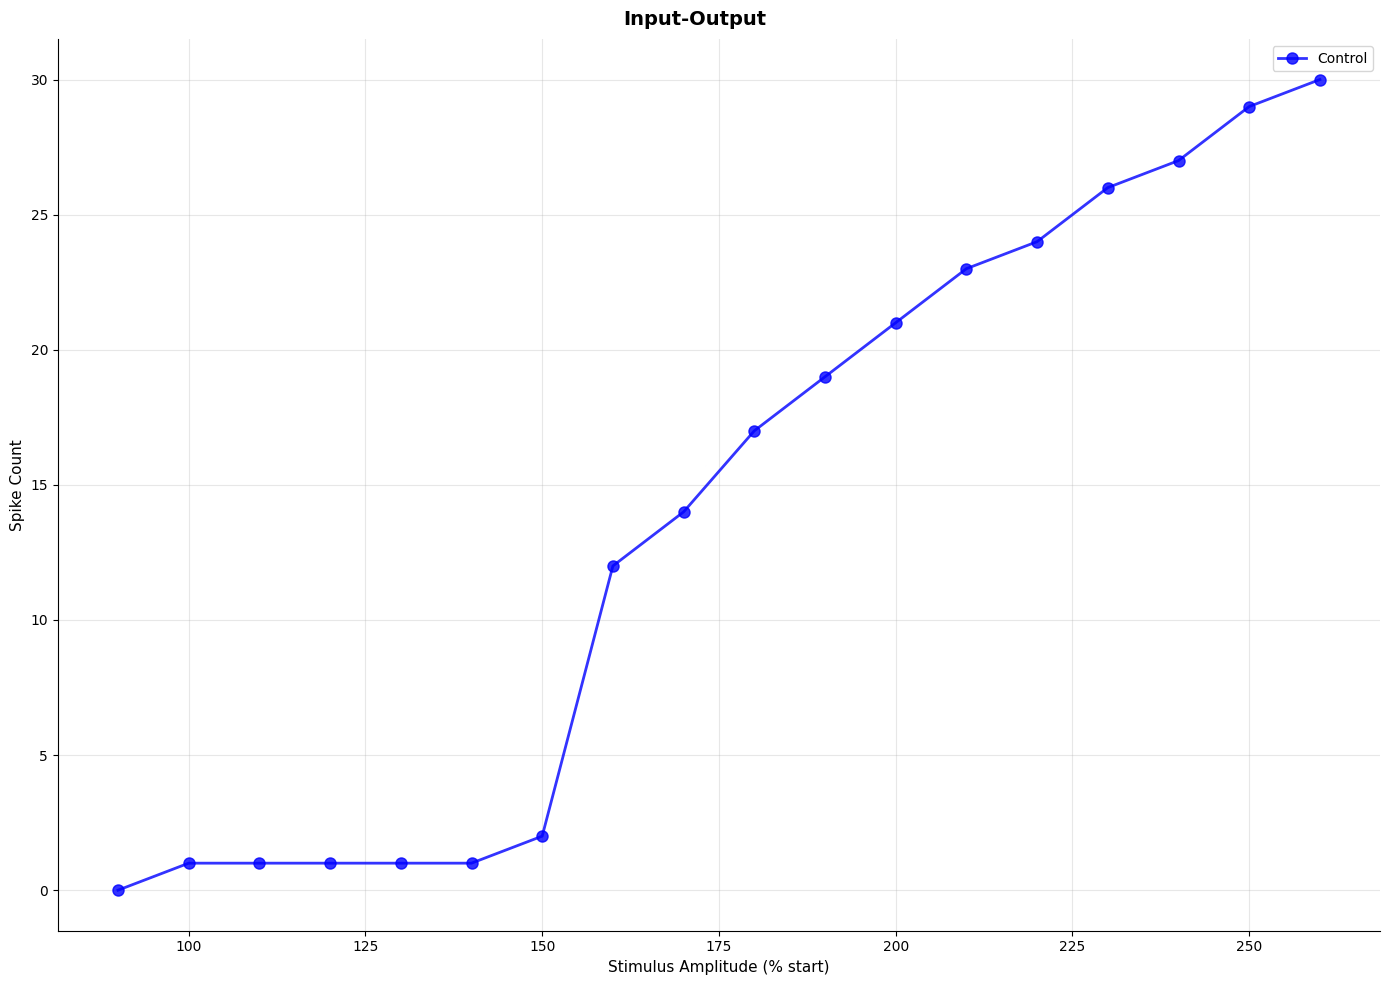


Feature Summary by Stimulus Amplitude:

Step_90:
  Spike Count:      Control=0

Step_100:
  Spike Count:      Control=1

Step_110:
  Spike Count:      Control=1

Step_120:
  Spike Count:      Control=1

Step_130:
  Spike Count:      Control=1

Step_140:
  Spike Count:      Control=1

Step_150:
  Spike Count:      Control=2

Step_160:
  Spike Count:      Control=12

Step_170:
  Spike Count:      Control=14

Step_180:
  Spike Count:      Control=17

Step_190:
  Spike Count:      Control=19

Step_200:
  Spike Count:      Control=21

Step_210:
  Spike Count:      Control=23

Step_220:
  Spike Count:      Control=24

Step_230:
  Spike Count:      Control=26

Step_240:
  Spike Count:      Control=27

Step_250:
  Spike Count:      Control=29

Step_260:
  Spike Count:      Control=30


In [15]:
## Visualize Extracted Features

import matplotlib.pyplot as plt

# Create a figure with subplots for each feature
fig, ax = plt.subplots(figsize=(14, 10))

# Features to plot
features_to_plot = [
    ('spike_count', 'Spike Count'),
]
    
# Get control data
control_data = features_df[features_df['campaign'] == 'control']

# Plot control
ax.plot(control_data['percent_start'], control_data[feature_name], 
        'o-', color='blue', linewidth=2, markersize=8, label='Control', alpha=0.8)


# Format plot
ax.set_xlabel('Stimulus Amplitude (% start)', fontsize=11)
ax.set_ylabel(feature_label, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Input-Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFeature Summary by Stimulus Amplitude:")
print("="*80)
for step in sorted(features_df['percent_start'].unique()):
    print(f"\nStep_{int(step)}:")
    control_row = features_df[(features_df['percent_start'] == step) & (features_df['campaign'] == 'control')].iloc[0]    
    print(f"  Spike Count:      Control={control_row['spike_count']:.0f}")